In [17]:
from langgraph.graph import StateGraph ,START, END
from typing import TypedDict

In [18]:
class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int

    sr: float
    bpb: float
    boundry_percentage: float

    summary: str

    

In [19]:
def calculate_sr(state: BatsmanState) -> BatsmanState:
    runs = state["runs"]
    balls = state["balls"]
    sr = (runs / balls) *100
    state["sr"] = sr
    return {"sr": sr}
  
def calculate_bpb(state: BatsmanState) -> BatsmanState:  
    fours = state["fours"]
    sixes = state["sixes"]
    balls = state["balls"]
    bpb = balls/(fours + sixes)
    state["bpb"] = bpb
    return {"bpb": bpb}
def calculate_boundry_percentage(state: BatsmanState) -> BatsmanState:  
    fours = state["fours"]
    sixes = state["sixes"]
    runs = state["runs"]
    boundry_percentage = (fours*4 + sixes*6)/runs
    state["boundry_percentage"] = boundry_percentage
    return {"boundry_percentage": boundry_percentage}
def summary(state: BatsmanState) -> BatsmanState:
    summary=f"""
    sr: {state['sr']} \n
    bpb: {state['bpb']} \n
    boundry_percentage: {state['boundry_percentage']} \n
    """
    state["summary"] = summary
    return {"summary": summary}

In [20]:
graph = StateGraph(BatsmanState)

graph.add_node("calculate_sr",calculate_sr)
graph.add_node("calculate_bpb",calculate_bpb)
graph.add_node("calculate_boundry_percentage",calculate_boundry_percentage)
graph.add_node("summary",summary)

graph.add_edge(START, "calculate_sr")
graph.add_edge(START, "calculate_bpb")
graph.add_edge(START, "calculate_boundry_percentage")

graph.add_edge("calculate_sr", "summary")
graph.add_edge("calculate_bpb", "summary")
graph.add_edge("calculate_boundry_percentage", "summary")

graph.add_edge("summary", END)


{'runs': 100, 'balls': 100, 'fours': 10, 'sixes': 5, 'sr': 100.0, 'bpb': 6.666666666666667, 'boundry_percentage': 0.7, 'summary': '\n    sr: 100.0 \n\n    bpb: 6.666666666666667 \n\n    boundry_percentage: 0.7 \n\n    '}


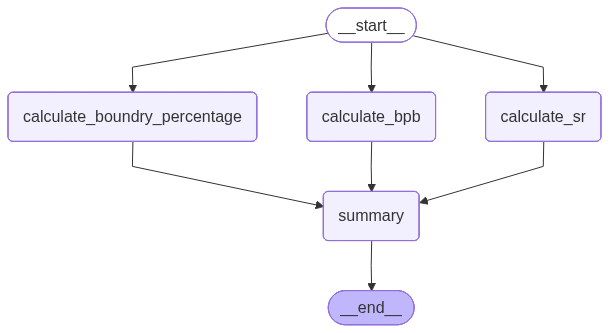

In [21]:
workflow = graph.compile()

initial_state = {"runs": 100, "balls": 100, "fours": 10, "sixes": 5}

final_state = workflow.invoke(initial_state)

print(final_state)

from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())